# EDA & Preprocessing




In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("..") / "data" / "raw"
ID_COL, TARGET_COL = "PassengerId", "Survived"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"train: {train.shape},  test: {test.shape}")


train: (891, 12),  test: (418, 11)


## 1. First look


In [2]:
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Basic info




In [3]:
print(f"samples: train={len(train)}, test={len(test)}")
print(f"features (без target): {train.shape[1] - 1}")
print()
print("dtypes:")
print(train.dtypes.to_string())


samples: train=891, test=418
features (без target): 11

dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str


## 3. Duplicates



In [4]:
print(f"duplicate IDs in train: {train[ID_COL].duplicated().sum()}")
print(f"duplicate IDs in test:  {test[ID_COL].duplicated().sum()}")

content_cols = [c for c in train.columns if c not in {ID_COL, TARGET_COL}]
print(f"full-row duplicates (train, без ID/target): {train[content_cols].duplicated().sum()}")


duplicate IDs in train: 0
duplicate IDs in test:  0
full-row duplicates (train, без ID/target): 0


## 4. Unique values


In [5]:
nunique = train.nunique().sort_values()
ratio = (nunique / len(train)).round(3)
pd.DataFrame({"nunique": nunique, "ratio": ratio})


,nunique,ratio
Survived,2,0.002
Sex,2,0.002
Pclass,3,0.003
Embarked,3,0.003
Parch,7,0.008
SibSp,7,0.008
Age,88,0.099
Cabin,147,0.165
Fare,248,0.278
Ticket,681,0.764


## 5. Correlation & leakage


In [6]:
numeric = train.select_dtypes(include=[np.number]).drop(columns=[ID_COL])
corr_with_target = (
    numeric.corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_with_target.to_frame("pearson_with_target").round(3)


,pearson_with_target
Pclass,-0.338
Fare,0.257
Parch,0.082
Age,-0.077
SibSp,-0.035


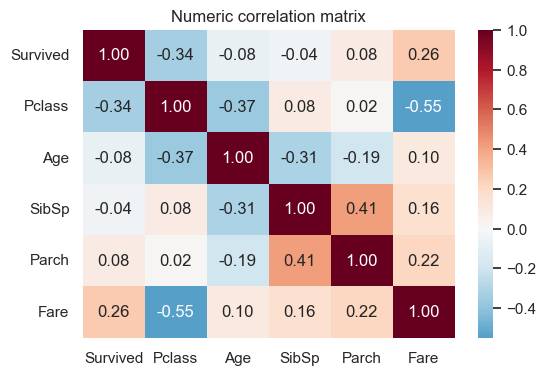

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Numeric correlation matrix")
plt.show()


## 6. NaNs


In [8]:
nan_stats = pd.DataFrame({
    "nan_train": train.isna().sum(),
    "ratio_train": train.isna().mean().round(3),
    "nan_test": test.isna().sum().reindex(train.columns).fillna(0).astype(int),
})
nan_stats[nan_stats["nan_train"] + nan_stats["nan_test"] > 0]


,nan_train,ratio_train,nan_test
Age,177,0.199,86
Fare,0,0.000,1
Cabin,687,0.771,327
Embarked,2,0.002,0


In [9]:
nan_target_corr = (
    train.isna()
    .astype(int)
    .corrwith(train[TARGET_COL])
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
nan_target_corr.to_frame("corr(NaN-mask, Survived)").round(3)


C:\Users\kamaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\kamaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,"corr(NaN-mask, Survived)"
Cabin,-0.317
Age,-0.092
Embarked,0.060


## 7. Target analysis


In [10]:
counts = train[TARGET_COL].value_counts()
ratio = train[TARGET_COL].value_counts(normalize=True).round(3)
pd.DataFrame({"count": counts, "ratio": ratio})


,count,ratio
Survived,,
0,549,0.616
1,342,0.384


## 8. Feature distribution


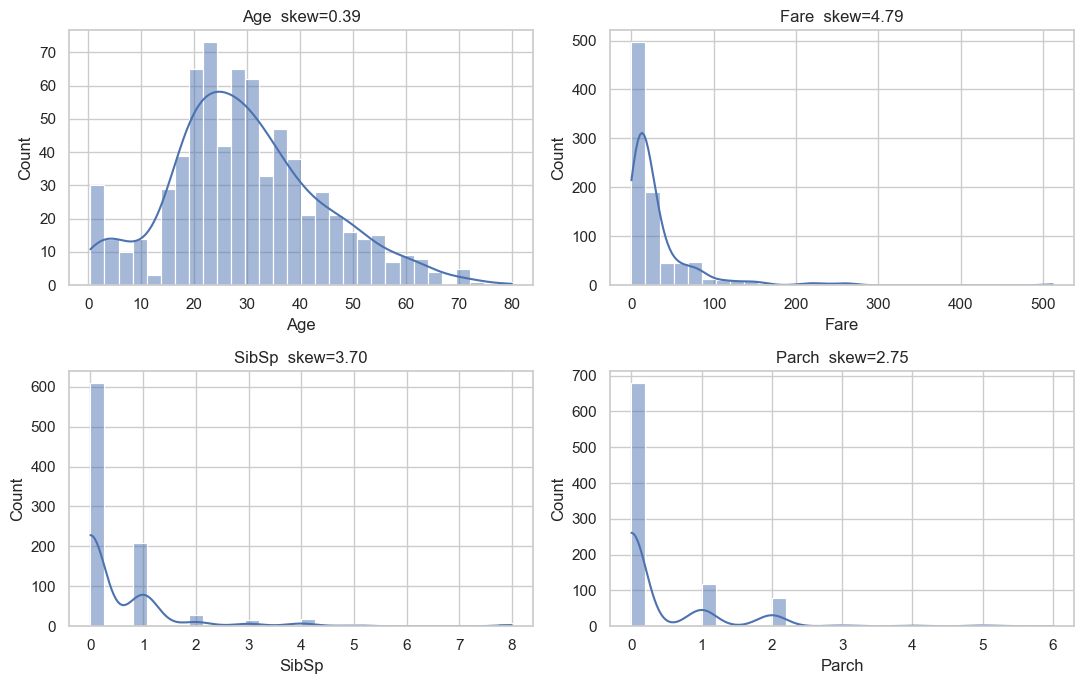

In [11]:
num_features = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feature in zip(axes.flat, num_features):
    sns.histplot(train[feature].dropna(), bins=30, ax=ax, kde=True)
    ax.set_title(f"{feature}  skew={train[feature].skew():.2f}")
fig.tight_layout()
plt.show()


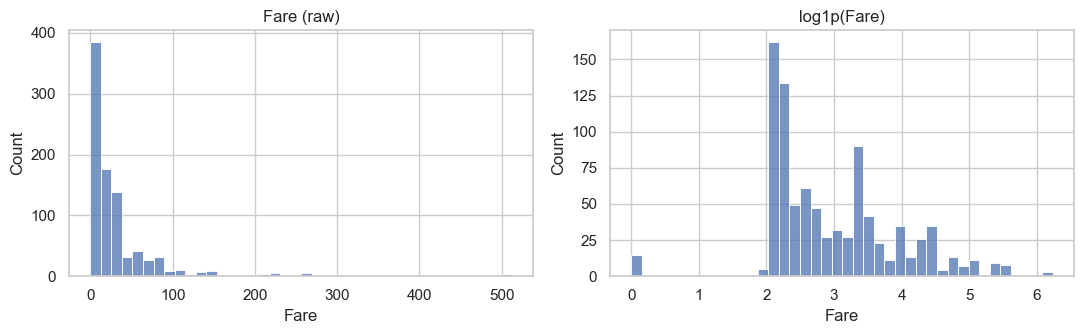

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train["Fare"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Fare (raw)")
sns.histplot(np.log1p(train["Fare"].dropna()), bins=40, ax=axes[1])
axes[1].set_title("log1p(Fare)")
fig.tight_layout()
plt.show()


## 9. Categorical features


In [13]:
cat_features = ["Pclass", "Sex", "Embarked"]
for feature in cat_features:
    print(feature)
    print(
        train.groupby(feature)[TARGET_COL]
        .agg(["count", "mean"])
        .rename(columns={"mean": "survival_rate"})
        .round(3)
    )
    print()


Pclass
        count  survival_rate
Pclass                      
1         216          0.630
2         184          0.473
3         491          0.242

Sex
        count  survival_rate
Sex                         
female    314          0.742
male      577          0.189

Embarked
          count  survival_rate
Embarked                      
C           168          0.554
Q            77          0.390
S           644          0.337



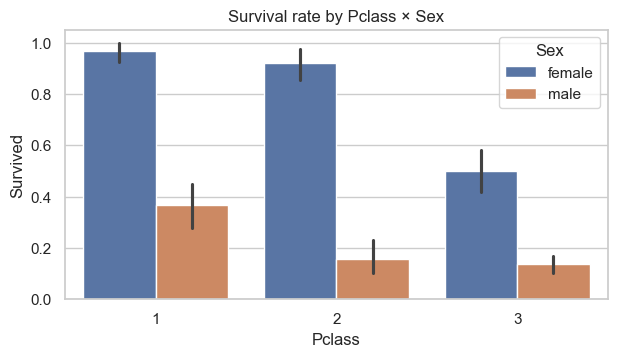

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=train, x="Pclass", y=TARGET_COL, hue="Sex", ax=ax)
ax.set_title("Survival rate by Pclass × Sex")
plt.show()


## 10. Engineered features preview


In [15]:
title = train["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print("Title (top-15):")
print(title.value_counts().head(15))


Title (top-15):
Name
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Mme         1
Ms          1
Lady        1
Sir         1
Capt        1
Name: count, dtype: int64


In [16]:
family = train["SibSp"] + train["Parch"] + 1
print("FamilySize × survival rate:")
print(
    train.assign(FamilySize=family)
    .groupby("FamilySize")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
    .round(3)
)


FamilySize × survival rate:
            count  survival_rate
FamilySize                      
1             537          0.304
2             161          0.553
3             102          0.578
4              29          0.724
5              15          0.200
6              22          0.136
7              12          0.333
8               6          0.000
11              7          0.000


In [17]:
deck = train["Cabin"].dropna().str[0]
print("Deck × survival rate (где Cabin известен):")
print(
    train.assign(Deck=deck)
    .dropna(subset=["Deck"])
    .groupby("Deck")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
    .round(3)
)


Deck × survival rate (где Cabin известен):
      count  survival_rate
Deck                      
A        15          0.467
B        47          0.745
C        59          0.593
D        33          0.758
E        32          0.750
F        13          0.615
G         4          0.500
T         1          0.000


## 12. Scaling & distribution transformation


In [18]:
age_bins = pd.cut(
    train["Age"],
    bins=[0, 12, 18, 30, 45, 60, 100],
    labels=["child", "teen", "yadult", "adult", "midage", "senior"],
)
fare_bins = pd.qcut(
    train["Fare"].fillna(train["Fare"].median()),
    q=4,
    labels=["low", "mid", "high", "vhigh"],
)
print("AgeBin × survival rate:")
print(train.assign(AgeBin=age_bins).groupby("AgeBin", observed=False)[TARGET_COL].mean().round(3))
print()
print("FareBin × survival rate:")
print(train.assign(FareBin=fare_bins).groupby("FareBin", observed=False)[TARGET_COL].mean().round(3))


AgeBin × survival rate:
AgeBin
child     0.580
teen      0.429
yadult    0.356
adult     0.426
midage    0.407
senior    0.227
Name: Survived, dtype: float64

FareBin × survival rate:
FareBin
low      0.197
mid      0.304
high     0.455
vhigh    0.581
Name: Survived, dtype: float64
